# Openness to experience and YouTube content diversity: A digital citizen science analysis

**Name:** Wenyuan Yang \
**Student number:**   \
**Email:**   \
**Date:** 23 September 2026  \
**Lecturer:**  \
**Course:** Applied Digital Citizen Science  \
**Word count:** 2,475

In [2]:
import json, os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Introduction

Openness to experience is one of the five personality dimensions in the Big Five model (Costa & McCrae, 1992). It involves individual differences in active imagination, aesthetic sensitivity, attentiveness to inner feelings, preference for variety, intellectual curiosity, and challenging authority (Costa & McCrae, 1992). People who score high on openness tend to engage with complex and abstract topics, reflect on ideas, and appreciate variety. In contrast, people who score low on openness prefer routine and concrete thinking (Costa & McCrae, 1992).

Content diversity describes how a person's media consumption is distributed across different types of content. For example, a viewer who watches only music videos has low content diversity. In constrast, a viewer who watches music, news, education, comedy, and gaming videos in roughly equal proportions has higher content diversity. Shannon entropy provides a formal measure of this distribution (Shannon, 1948). Entropy equals zero when all viewing falls in one category and reaches its maximum when viewing is spread evenly across all available categories.

Understanding what drives content diversity on platforms like YouTube matters because current debates attribute narrow consumption primarily to algorithmic personalisation and filter bubbles (Pariser, 2011). If individual differences such as personality also shape how diverse a person's media diet is, then the causes of narrow consumption are not purely algorithmic. Sindermann et al. (2020) found that openness to experience positively predicted the number of different news sources people consumed, but their measure relied on self-reports. Using donated digital trace data (actual watch histories) rather than self-reported media use provides a more direct test of this relationship.

Against this backdrop, this study asks: does openness to experience predict YouTube users' diversity of content consumption?

The expected relationship follows from how openness is defined. Two of its dimensions, intellectual curiosity and a preference for variety, describe a tendency to look beyond familiar content (Costa & McCrae, 1992). Openness also shapes media choices in practice. Rentfrow and Gosling (2003) found that people high in openness preferred reflective and complex music, such as jazz and classical, and intense and rebellious music, such as rock, and liked upbeat and conventional music less. If openness shapes which kinds of music people choose, it may also shape how widely they range across YouTube, where videos span 17 categories from Music to Science and Technology.

**H1:** YouTube users with higher scores on openness to experience display higher content diversity in their YouTube watch history.

# Methods

## Procedure

This study uses a digital citizen science approach, in which participants donate their own digital trace data for scientific study. I combine these donated traces with survey responses to study how self-reported traits relate to actual platform behaviour (Strycharz et al., 2024). Donated log data records what people do, while surveys capture what people think and feel.

Data were collected through the LISS panel, a probability based online panel of Dutch households administered by Centerdata (2026). Panel members completed a questionnaire on Qualtrics containing items from multiple LISS survey modules, including the Personality study (wave 2025) and the Background Variables study (wave 2026). After completing the questionnaire, participants were invited to donate their YouTube data through the Port data donation tool, which opened with an informed consent page stating the Data Donation Packages (DDP) they are asked for (e.g., "Your watch history"). Participants who accepted downloaded their YouTube data package from Google Takeout and uploaded it to the Port platform, which extracted the watch history and transmitted it to the researcher.

Video metadata was not part of the donated data. The YouTube Data API was queried separately using the video IDs found in the watch histories. This API lookup provided content categories, video durations, and view counts for most of the watched videos.

## Sample

The questionnaire was started by 2,463 respondents, of whom 1,478 completed it. The donation step produced 438 YouTube packages covering 421 participants. Thirteen packages could not be read, because the watch history was stored as plain text rather than as structured records. Three came from pilot accounts, which contained no viewings. Seventeen participants uploaded twice, and in every one of these cases the second upload was an exact copy of the first. The repeated viewings were therefore dropped and one row per viewing was kept. This left 405 participants with a usable watch history.

All 405 had completed the questionnaire, so the losses that follow are unanswered items rather than unfinished questionnaires. Of these 405, 372 had complete data on every analysis variable. Two were lost because none of their watched videos could be matched to an API category, leaving no entropy to compute, and 31 because they left at least one openness item blank. A further 115 were lost because they gave a non-response answer on at least one of the ten openness items. The LISS data records these as −8 and −9, outside the five answer categories. One respondent reported a gender category containing a single case, too few to estimate a coefficient, and was excluded. The final sample comprised 256 participants (*M*age = 41.5, *SD* = 17.7, range 18 to 87, 53.1% female).

## Measures

**Openness to experience** was measured with 10 items from the IPIP Big Five Factor V scale (Goldberg, 1992), included in the LISS Personality module (variable prefix cp25q, wave 2025). The items measure the intellectual curiosity and imagination dimensions of openness, with statements such as "I have a rich vocabulary," "I have a vivid imagination," and "I am quick to understand things" (International Personality Item Pool, n.d.). The scale does not cover other facets of openness such as aesthetic sensitivity or preference for variety, which are part of Costa and McCrae's (1992) broader construct. Items were scored on a 5-point scale ranging from 1 ("very inaccurate") to 5 ("very accurate"). Three items were reverse coded (e.g. "I have difficulty understanding abstract ideas"). The composite was the mean of all 10 items. Internal consistency was excellent (Cronbach's α = .94, 95% CI [.92, .95]).

**Content diversity** was operationalised as Shannon (1948) entropy of the distribution of watched videos across YouTube content categories. Each video in a participant's donated watch history was matched to its content category using the API metadata. Of the 698,633 donated viewings, 637,284 (91.2%) matched a video in the API tables. Shannon entropy was computed as

$$H = -\sum_{i=1}^{17} p_i \log_2 p_i$$

where $p_i$ is the share of the participant's categorised viewings that fall in category $i$. Viewings without a category were left out, a video watched twice counts twice, and a category with no viewings contributes zero. With 17 categories available, entropy ranges from 0, when all viewing falls in one category, to $\log_2 17 = 4.09$ bits, when viewing is spread evenly over all 17. Higher values indicate more diverse viewing.

**Control variables** included age in years (LISS Background Variables), gender (1 = male, 2 = female), and the log-transformed total number of videos in the donated watch history. The video count was log-transformed because entropy rises with diminishing returns as viewing grows. In the analysis sample, entropy correlates more strongly with the logged count (*r* = .57) than with the raw count (*r* = .22).

## Analytical approach

The hypothesis was tested using ordinary least squares (OLS) regression with content diversity as the dependent variable. Openness to experience was the independent variable, and age, gender, and log(video count) were controls. OLS was chosen because both the dependent variable and the main independent variable are continuous and the research question concerns a linear association. The variance inflation factor (VIF) was computed to check for multicollinearity.

## Data loading and preparation

In [3]:
# Load survey data (skip the description row)
survey = pd.read_excel(
    '14803119_15/ADCS-2026-student15_September+14,+2026_11.27.xlsx',
    skiprows=[1]
)
print(f"Survey respondents: {len(survey)}")
print(f"Columns: {len(survey.columns)}")
survey.head(3)

Survey respondents: 2463
Columns: 131


,StartDate,EndDate,Status,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,UserLanguage,...,cp25q024,cp25q029,cp25q034,cp25q039,cp25q044,cp25q049,cp25q054,cp25q059,cp25q064,cp25q069
0,2026-09-10 19:22:00,2026-09-10 19:25:03,0,71,183,0,2026-09-10 19:25:03,R_SeiwXF2mlniN5qd,anonymous,EN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-09-08 08:53:00,2026-09-08 09:21:27,0,100,1707,1,2026-09-08 09:21:27,R_Cr6sdZsaPN49tvH,anonymous,EN,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,4.0,4.0
2,2026-09-05 11:53:00,2026-09-05 12:04:47,0,100,707,1,2026-09-05 12:04:47,R_A7vqWTxxEYcXu8W,anonymous,EN,...,4.0,2.0,4.0,2.0,4.0,2.0,4.0,4.0,5.0,5.0


In [4]:
# Load the API metadata and merge to make the video-category dataframe
videos_api = pd.read_csv('14803119_15/api/youtube_videos_api.csv')
categories = pd.read_csv('14803119_15/api/youtube_categories.csv')
print('videos in API:', len(videos_api))
print('categories:', len(categories))

video_metadata = pd.merge(
    videos_api[['video_id', 'video_categoryId']],
    categories[['categoryId', 'category_title']],
    how='left', left_on='video_categoryId', right_on='categoryId'
)

# One row per video, so the merge onto the watch history cannot duplicate viewings
video_metadata = video_metadata[['video_id', 'category_title']].drop_duplicates(subset='video_id')
print('rows in video_metadata:', len(video_metadata))
print(categories[['categoryId', 'category_title']])

videos in API: 243248
categories: 17
rows in video_metadata: 242279
    categoryId        category_title
0            1      Film & Animation
1            2      Autos & Vehicles
2           10                 Music
3           15        Pets & Animals
4           17                Sports
5           19       Travel & Events
6           20                Gaming
7           22        People & Blogs
8           23                Comedy
9           24         Entertainment
10          25       News & Politics
11          26         Howto & Style
12          27             Education
13          28  Science & Technology
14          30                Movies
15          42                Shorts
16          44              Trailers


In [5]:
# extract_consolidate_donations from Scripts.ipynb
# The dataset is saved as .csv instead of the original .xlsx, otherwise it's too slow
def extract_consolidate_donations(input_path, source, key, output_path, output_filename):
        files = os.listdir(input_path)
        files = [f for f in files if f.endswith('.json') and source in f]
        print('found', len(files), 'files')

        results = pd.DataFrame()
        errors = []

        for file in files:
            try:
                with open(os.path.join(input_path, file), 'r') as f:
                    tmp_json = json.load(f)
                    for item in tmp_json:
                        if key in item.keys():
                            donations = item[key]
                            tmp_df = pd.DataFrame(item[key])
                            tmp_df['filename'] = file
                            tmp_df['file_creation_date'] = file.split('_')[0]
                            tmp_df['participant'] = file.split('participant=')[1].split('_source')[0]
                            results = pd.concat([results, tmp_df], ignore_index=True)
            except Exception as e:
                errors.append({'filename': file, 'error': str(e)})

        results.to_csv(os.path.join(output_path, output_filename + '.csv'), index=False)
        if len(errors) > 0:
            pd.DataFrame(errors).to_csv(os.path.join(output_path, output_filename + '_errors.csv'), index=False)

        print('saved', os.path.join(output_path, output_filename + '.csv'))

        return


input_path = '14803119_15/donations'
source = 'YouTube'
key = 'youtube_watch_history'
output_path = '14803119_15'
output_filename = 'youtube_watch_history'

In [6]:
extract_consolidate_donations(input_path, source, key, output_path, output_filename)

found 438 files
saved 14803119_15/youtube_watch_history.csv


In [7]:
# Load the consolidated watch history
donations = pd.read_csv('14803119_15/youtube_watch_history.csv')

# Accounting for the 438 donation files, so that every participant lost before the analysis can be traced to a reason
files = os.listdir('14803119_15/donations')
files = [f for f in files if f.endswith('.json') and 'YouTube' in f]
file_participants = pd.Series([f.split('participant=')[1].split('_source')[0] for f in files])

# The extraction function above wrote the files it could not parse to an errors file
errors = pd.read_csv('14803119_15/youtube_watch_history_errors.csv')
pilot = file_participants[file_participants.str.contains('test')].unique()
upload_counts = file_participants.value_counts()
uploaded_twice = upload_counts[upload_counts > 1]

print('donation files:                  ', len(files))
print('unique participants in the files:', file_participants.nunique())
print('files that could not be read:    ', len(errors))
print('pilot accounts:                  ', len(pilot), list(pilot))
print('participants who uploaded twice: ', len(uploaded_twice))
print()
print('reason for each file that does not become a participant:')
print(' ', len(files), '- ', len(uploaded_twice), '(second uploads) -', len(errors),
      '(unreadable) -', len(pilot), '(pilot) =',
      len(files) - len(uploaded_twice) - len(errors) - len(pilot))
print('participants in the consolidated data:', donations['participant'].nunique())
print()
print(errors['error'].value_counts())

donation files:                   438
unique participants in the files: 421
files that could not be read:     13
pilot accounts:                   3 ['g15_test_9002', 'g15_test_9001', 'g15_test_9000']
participants who uploaded twice:  17

reason for each file that does not become a participant:
  438 -  17 (second uploads) - 13 (unreadable) - 3 (pilot) = 405
participants in the consolidated data: 405

error
'str' object has no attribute 'keys'    13
Name: count, dtype: int64


In [8]:
# Removing duplicates from the 17 participants who uploaded twice
pooled = donations[donations['participant'].isin(uploaded_twice.index)]
unique_rows = pooled.drop_duplicates(subset=['participant', 'Url', 'Date standard format'])
print('pooled rows for these 17 participants:', len(pooled))
print('distinct viewings among them:         ', len(unique_rows))

# Keeping one row per viewing
print()
print('rows before:', len(donations))
donations = donations.drop_duplicates(subset=['participant', 'Url', 'Date standard format'])
print('rows after: ', len(donations))
print('participants:', donations['participant'].nunique())

donations.head()

pooled rows for these 17 participants: 56174
distinct viewings among them:          28087

rows before: 726720
rows after:  698633
participants: 405


,Title,Url,Advertisement,Channel,Date,Date standard format,filename,file_creation_date,participant
0,One minute recipe #shorts,https://www.youtube.com/watch?v=_9VI-_NMRry_adcs,No,YouTube Shorts,"Aug 30, 2026, 6:53:32 PM CEST",2026-08-30T18:53:32,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947
1,48 hours in Rotterdam #59,https://www.youtube.com/watch?v=nmBL6NCht52_adcs,No,Lost LeBlanc,"Aug 30, 2026, 6:50:11 PM CEST",2026-08-30T18:50:11,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947
2,Beating Terraria without taking damage,https://www.youtube.com/watch?v=g4yVe_hJL33_adcs,No,Dream,"Aug 30, 2026, 6:50:00 PM CEST",2026-08-30T18:50:00,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947
3,The physics of a perfect free kick | Part 7,https://www.youtube.com/watch?v=WWF3g6yCcNy_adcs,No,Tom Scott,"Aug 30, 2026, 6:37:05 PM CEST",2026-08-30T18:37:05,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947
4,Energy prices fall for the third month running,https://www.youtube.com/watch?v=QxegLpb23aq_adcs,No,NOS op 3,"Aug 30, 2026, 6:33:32 PM CEST",2026-08-30T18:33:32,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947


In [12]:
# Creating a common column with the video identifier
# The TikTok version split the link on '/'; a YouTube watch URL ends in '?v=<id>', so it splits on '='.
def return_video_id(link):
    if link:
        return str(link).split('=')[-1]
    return

# Testing with one example
print(return_video_id(donations.iloc[0]['Url']))

donations['video_id'] = donations['Url'].apply(return_video_id)
donations.head()

_9VI-_NMRry_adcs


,Title,Url,Advertisement,Channel,Date,Date standard format,filename,file_creation_date,participant,video_id
0,One minute recipe #shorts,https://www.youtube.com/watch?v=_9VI-_NMRry_adcs,No,YouTube Shorts,"Aug 30, 2026, 6:53:32 PM CEST",2026-08-30T18:53:32,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,_9VI-_NMRry_adcs
1,48 hours in Rotterdam #59,https://www.youtube.com/watch?v=nmBL6NCht52_adcs,No,Lost LeBlanc,"Aug 30, 2026, 6:50:11 PM CEST",2026-08-30T18:50:11,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,nmBL6NCht52_adcs
2,Beating Terraria without taking damage,https://www.youtube.com/watch?v=g4yVe_hJL33_adcs,No,Dream,"Aug 30, 2026, 6:50:00 PM CEST",2026-08-30T18:50:00,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,g4yVe_hJL33_adcs
3,The physics of a perfect free kick | Part 7,https://www.youtube.com/watch?v=WWF3g6yCcNy_adcs,No,Tom Scott,"Aug 30, 2026, 6:37:05 PM CEST",2026-08-30T18:37:05,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,WWF3g6yCcNy_adcs
4,Energy prices fall for the third month running,https://www.youtube.com/watch?v=QxegLpb23aq_adcs,No,NOS op 3,"Aug 30, 2026, 6:33:32 PM CEST",2026-08-30T18:33:32,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,QxegLpb23aq_adcs


In [14]:
# Merging category metadata onto the watch history
dataset_logs = pd.merge(donations, video_metadata, how='left', on='video_id')
print('rows before merge:', len(donations))
print('rows after merge: ', len(dataset_logs))
print('videos matched to a category:', dataset_logs['category_title'].notna().sum())
dataset_logs.head()

rows before merge: 698633
rows after merge:  698633
videos matched to a category: 637284


,Title,Url,Advertisement,Channel,Date,Date standard format,filename,file_creation_date,participant,video_id,category_title
0,One minute recipe #shorts,https://www.youtube.com/watch?v=_9VI-_NMRry_adcs,No,YouTube Shorts,"Aug 30, 2026, 6:53:32 PM CEST",2026-08-30T18:53:32,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,_9VI-_NMRry_adcs,Shorts
1,48 hours in Rotterdam #59,https://www.youtube.com/watch?v=nmBL6NCht52_adcs,No,Lost LeBlanc,"Aug 30, 2026, 6:50:11 PM CEST",2026-08-30T18:50:11,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,nmBL6NCht52_adcs,Travel & Events
2,Beating Terraria without taking damage,https://www.youtube.com/watch?v=g4yVe_hJL33_adcs,No,Dream,"Aug 30, 2026, 6:50:00 PM CEST",2026-08-30T18:50:00,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,g4yVe_hJL33_adcs,Gaming
3,The physics of a perfect free kick | Part 7,https://www.youtube.com/watch?v=WWF3g6yCcNy_adcs,No,Tom Scott,"Aug 30, 2026, 6:37:05 PM CEST",2026-08-30T18:37:05,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,WWF3g6yCcNy_adcs,NaN
4,Energy prices fall for the third month running,https://www.youtube.com/watch?v=QxegLpb23aq_adcs,No,NOS op 3,"Aug 30, 2026, 6:33:32 PM CEST",2026-08-30T18:33:32,2026-09-10_participant=g15_survey_3947_source=...,2026-09-10,g15_survey_3947,QxegLpb23aq_adcs,News & Politics


In [16]:
# Aggregating at individual level

# Number of videos watched
count_videos_watched = pd.pivot_table(dataset_logs, index='participant', values='Url', aggfunc='count').reset_index()
count_videos_watched = count_videos_watched.rename(columns={'Url': 'count_videos_watched'})

# Number of distinct categories watched
count_categories = pd.pivot_table(dataset_logs, index='participant', values='category_title', aggfunc='nunique').reset_index()
count_categories = count_categories.rename(columns={'category_title': 'count_categories'})

count_videos_watched.head()

,participant,count_videos_watched
0,g15_survey_1003,1668
1,g15_survey_1026,1154
2,g15_survey_1030,1521
3,g15_survey_1039,2172
4,g15_survey_1059,1981


In [ ]:
# Content entropy per participant
# The same pivot_table as above, but with categories in the columns, gives one row per participant and one column per category
category_counts = pd.pivot_table(
    dataset_logs, index='participant', columns='category_title', values='Url', aggfunc='count'
).fillna(0)

# Shannon entropy is then computed over the row proportions
proportions = category_counts.div(category_counts.sum(axis=1), axis=0)

# The + 0 turns the floating point -0.0 of a single-category participant into 0.0
entropy = -(proportions * np.log2(proportions.where(proportions > 0))).sum(axis=1) + 0

content_entropy = entropy.reset_index()
content_entropy.columns = ['participant', 'content_entropy']

print(category_counts.shape, '(participants, categories)')
content_entropy.head()

(403, 17) (participants, categories)


,participant,content_entropy
0,g15_survey_1003,3.042263
1,g15_survey_1026,3.398565
2,g15_survey_1030,3.602600
3,g15_survey_1039,3.167043
4,g15_survey_1059,3.669839


In [ ]:
# Combining the three aggregated log variables into one dataset
log_data = count_videos_watched.merge(count_categories, how='left', on='participant')
log_data = log_data.merge(content_entropy, how='left', on='participant')

print('participants in the log data:', len(log_data))
log_data.head()

participants in the log data: 405


,participant,count_videos_watched,count_categories,content_entropy
0,g15_survey_1003,1668,17,3.042263
1,g15_survey_1026,1154,17,3.398565
2,g15_survey_1030,1521,17,3.602600
3,g15_survey_1039,2172,17,3.167043
4,g15_survey_1059,1981,17,3.669839


## Checks on data preparation

In [ ]:
# Check 1: does the aggregated count match the raw donation file?
# Pick one participant and compare the JSON with the pivot_table output
sample_pid = log_data.iloc[5]['participant']
sample_file = [f for f in os.listdir('14803119_15/donations')
               if sample_pid in f and 'YouTube' in f][0]

with open(os.path.join('14803119_15/donations', sample_file)) as f:
    sample_json = json.load(f)
for item in sample_json:
    if 'youtube_watch_history' in item:
        raw_count = len(item['youtube_watch_history'])
        break

processed_count = log_data.loc[log_data['participant'] == sample_pid, 'count_videos_watched'].values[0]
print('participant:', sample_pid)
print('  raw watch history entries:', raw_count)
print('  aggregated video count:   ', processed_count)
print('  match:', raw_count == processed_count)

participant: g15_survey_1079
  raw watch history entries: 6519
  aggregated video count:    6519
  match: True


In [ ]:
# Check 2: does the entropy formula return the values it should?
# A participant spread evenly over 4 categories should score 2 bits, one who watches a single category should score 0 bits
test_uniform = pd.Series([0.25, 0.25, 0.25, 0.25])
print('uniform over 4 categories:', round(-(test_uniform * np.log2(test_uniform)).sum(), 1), '(expected 2.0)')

test_single = pd.Series([1.0])
print('single category:          ', round(-(test_single * np.log2(test_single)).sum(), 1), '(expected 0.0)')

# And the observed values sit inside the possible range for 17 categories
print('maximum possible entropy: ', round(np.log2(17), 2))
print('observed range:           ', round(log_data['content_entropy'].min(), 2),
      'to', round(log_data['content_entropy'].max(), 2))

uniform over 4 categories: 2.0 (expected 2.0)
single category:           -0.0 (expected 0.0)
maximum possible entropy:  4.09
observed range:            0.0 to 3.95


In [ ]:
# Check 3 and merge: survey and log data
# validate='one_to_one' raises an error if either side has a repeated participant, which would silently duplicate rows. indicator=True shows who is on each side of the merge
dataset = survey.merge(
    log_data, how='left', on='participant', indicator=True, validate='one_to_one'
)
print(dataset['_merge'].value_counts())
dataset = dataset.drop(columns='_merge')

print()
print('survey responses:        ', len(dataset))
print('responses with donation: ', dataset['count_videos_watched'].notna().sum())

_merge
left_only     2058
both           405
right_only       0
Name: count, dtype: int64

survey responses:         2463
responses with donation:  405


/var/folders/ly/prfh8d_s1x1c8r10j7fk270r0000gn/T/ipykernel_57827/833262319.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset = survey.merge(
/var/folders/ly/prfh8d_s1x1c8r10j7fk270r0000gn/T/ipykernel_57827/833262319.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset = survey.merge(


## Preparing the analysis sample

In [ ]:
# Openness items: IPIP Big Five Factor V (LISS Personality module, wave 2025)

openness_items = [
    'cp25q024', 'cp25q029', 'cp25q034', 'cp25q039', 'cp25q044',
    'cp25q049', 'cp25q054', 'cp25q059', 'cp25q064', 'cp25q069'
]
reverse_items = ['cp25q029', 'cp25q039', 'cp25q049']

# Keep respondents who donated a watch history and answered every analysis variable
donated = dataset[dataset['count_videos_watched'].notna()]
print('donated a usable watch history:', len(donated))
print('of whom Progress == 100:       ', (donated['Progress'] == 100).sum())
print()

# Now, the donors all completed the questionnaire, this step cleans unanswered items rather than unfinished questionnaires
print('no categorised video, so no entropy:', donated['content_entropy'].isna().sum())
with_entropy = donated[donated['content_entropy'].notna()]
print('left >= 1 openness item blank:      ', with_entropy[openness_items].isna().any(axis=1).sum())
print('missing age or gender:              ', donated[['leeftijd', 'geslacht']].isna().sum().sum())
print()

analysis = dataset.dropna(
    subset=['content_entropy', 'count_videos_watched', 'leeftijd', 'geslacht'] + openness_items
)
print('after dropna:', len(analysis))

donated a usable watch history: 405
of whom Progress == 100:        405

no categorised video, so no entropy: 2
left >= 1 openness item blank:       31
missing age or gender:               0

after dropna: 372


In [ ]:
# The openness items have five substantive answer categories, 1 to 5 (liss_variables.csv)
# There are -8 and -9 as values in the dataset, which needs to be filtered out as well 
invalid = []
for item in openness_items:
    invalid.append({
        'item': item,
        'code_minus9': (analysis[item] == -9).sum(),
        'code_minus8': (analysis[item] == -8).sum()
    })

invalid = pd.DataFrame(invalid)
print(invalid)
print()

# Some respondents gave a non-response answer on more than one item, ignore the overlap in the analysis sample
counts = (analysis[openness_items] < 0).sum(axis=1)
print('non-response answers per affected participant:')
print(counts[counts > 0].value_counts().sort_index())
print()

# Dropping them one item at a time
before_codes = len(analysis)
for item in openness_items:
    analysis = analysis[analysis[item] > 0]
print('before:', before_codes)
print('after keeping valid answers on all 10 items:', len(analysis))
print('lost to a non-response code on at least one item:', before_codes - len(analysis))

# Gender: one respondent is in a third category, too few to estimate a coefficient for
print()
print(analysis['geslacht'].value_counts())
analysis = analysis[analysis['geslacht'].isin([1, 2])].copy()
print('final analysis sample:', len(analysis))

       item  code_minus9  code_minus8
0  cp25q024           10            3
1  cp25q029           13            4
2  cp25q034            8            6
3  cp25q039           11            3
4  cp25q044            8            7
5  cp25q049           10            7
6  cp25q054            9            5
7  cp25q059           12            2
8  cp25q064            8            4
9  cp25q069            8            1

non-response answers per affected participant:
1    93
2    20
3     2
Name: count, dtype: int64

before: 372
after keeping valid answers on all 10 items: 257
lost to a non-response code on at least one item: 115

geslacht
2    136
1    120
3      1
Name: count, dtype: int64
final analysis sample: 256


In [ ]:
# Recoding the reversed items
for item in reverse_items:
    analysis[item] = analysis[item].replace({1: 5, 2: 4, 3: 3, 4: 2, 5: 1})

# Check: after recoding every item should correlate positively with the others
print('correlation of each item with cp25q024:')
print(analysis[openness_items].corr()['cp25q024'].round(2))

correlation of each item with cp25q024:
cp25q024    1.00
cp25q029    0.67
cp25q034    0.65
cp25q039    0.63
cp25q044    0.65
cp25q049    0.67
cp25q054    0.58
cp25q059    0.62
cp25q064    0.54
cp25q069    0.62
Name: cp25q024, dtype: float64


## Creating the openness variable and checking reliability

In [ ]:
# Creating new variable and calculating reliability
print(pg.cronbach_alpha(data=analysis[openness_items]))

analysis['openness'] = analysis[openness_items].mean(axis=1)
analysis['openness'].describe()

(np.float64(0.9356099310679815), array([0.923, 0.947]))


count    256.000000
mean       3.516406
std        0.696802
min        1.500000
25%        3.100000
50%        3.550000
75%        4.000000
max        5.000000
Name: openness, dtype: float64

In [ ]:
# Log transform of the video count, used as a control
analysis['log_videos'] = np.log1p(analysis['count_videos_watched'])
analysis[['count_videos_watched', 'log_videos']].describe().round(2)

,count_videos_watched,log_videos
count,256.00,256.00
mean,1871.13,6.49
std,2090.20,1.91
min,1.00,0.69
25%,227.75,5.43
50%,1108.00,7.01
75%,3294.00,8.10
max,9330.00,9.14


## Descriptive statistics

In [ ]:
# Sociodemographics of the analysis sample
print('N =', len(analysis))
print()
print('age:')
print(analysis['leeftijd'].describe().round(1))
print()
print('gender (1 = male, 2 = female):')
print(analysis['geslacht'].value_counts())
print()

# oplcat category labels from LISS
oplcat_labels = {
    1: 'primary school',
    2: 'vmbo',
    3: 'havo/vwo',
    4: 'mbo',
    5: 'hbo',
    6: 'wo'
}
print('education (oplcat):')
print(analysis['oplcat'].replace(oplcat_labels).value_counts().reindex(oplcat_labels.values()))

N = 256

age:
count    256.0
mean      41.5
std       17.7
min       18.0
25%       26.0
50%       37.0
75%       56.0
max       87.0
Name: leeftijd, dtype: float64

gender (1 = male, 2 = female):
geslacht
2    136
1    120
Name: count, dtype: int64

education (oplcat):
oplcat
primary school    17
vmbo              30
havo/vwo          30
mbo               60
hbo               77
wo                42
Name: count, dtype: int64


In [ ]:
# Key variables
key_vars = ['openness', 'content_entropy', 'count_videos_watched', 'log_videos', 'count_categories']
analysis[key_vars].describe().round(2)

,openness,content_entropy,count_videos_watched,log_videos,count_categories
count,256.00,256.00,256.00,256.00,256.00
mean,3.52,3.31,1871.13,6.49,15.68
std,0.70,0.69,2090.20,1.91,3.45
min,1.50,0.00,1.00,0.69,1.00
25%,3.10,3.19,227.75,5.43,17.00
50%,3.55,3.53,1108.00,7.01,17.00
75%,4.00,3.72,3294.00,8.10,17.00
max,5.00,3.95,9330.00,9.14,17.00


In [ ]:
# Numbers cited in the text that are not shown in the outputs above
print('r(entropy, log video count):', round(analysis['content_entropy'].corr(analysis['log_videos']), 2))
print('r(entropy, raw video count):', round(analysis['content_entropy'].corr(analysis['count_videos_watched']), 2))

categorised = category_counts.sum(axis=1)
low = analysis[analysis['content_entropy'] < 2]
print('participants below 2 bits:', len(low))
print('  of whom fewer than 100 categorised viewings:', (categorised[low['participant']] < 100).sum())
print('participants with an entropy of exactly 0:', (analysis['content_entropy'] == 0).sum())

r(entropy, log video count): 0.57
r(entropy, raw video count): 0.22
participants below 2 bits: 10
  of whom fewer than 100 categorised viewings: 9
participants with an entropy of exactly 0: 5


## Sample size per research stage

The table below shows the number of participants retained at each stage of the data collection and preparation pipeline, following the approach described by Strycharz et al. (2024).

In [ ]:
# Sample size at each stage (participant journey)
started = len(dataset)
completed = (dataset['Progress'] == 100).sum()
donated = dataset['count_videos_watched'].notna().sum()

complete_cases = len(dataset.dropna(
    subset=['content_entropy', 'count_videos_watched', 'leeftijd', 'geslacht'] + openness_items))
final = len(analysis)

stages = [
    ('Started the questionnaire', started),
    ('Completed the questionnaire', completed),
    ('Donated a usable YouTube watch history', donated),
    # Of the 33 lost at this stage, 2 have no categorised video (entropy cannot be computed) and 31 left an openness item blank
    ('No missing values on any analysis variable', complete_cases),
    ('Valid answers on all items (final sample)', final)
]

flow = []
for stage, n in stages:
    flow.append({
        'Stage': stage,
        'N': n,
        '% of started': round(n / started * 100, 1)
    })

flow = pd.DataFrame(flow)
flow['Lost at this stage'] = flow['N'].diff().fillna(0).astype(int)
flow

,Stage,N,% of started,Lost at this stage
0,Started the questionnaire,2463,100.0,0
1,Completed the questionnaire,1478,60.0,-985
2,Donated a usable YouTube watch history,405,16.4,-1073
3,No missing values on any analysis variable,372,15.1,-33
4,Valid answers on all items (final sample),256,10.4,-116


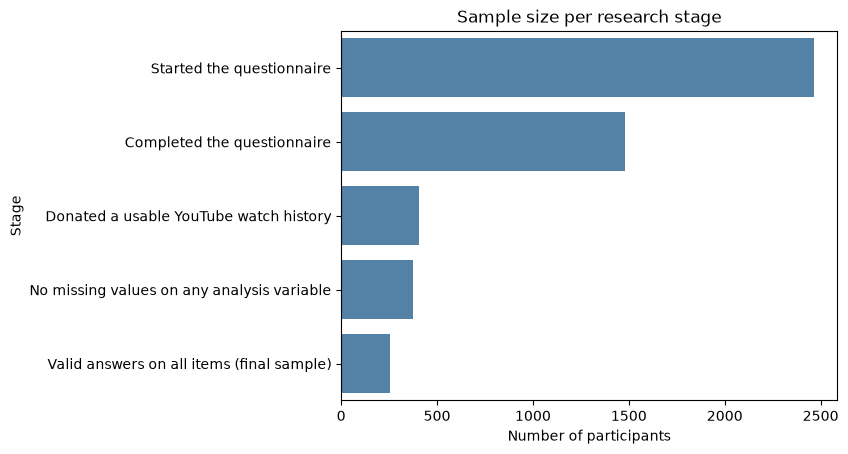

In [ ]:
sns.barplot(data=flow, x='N', y='Stage', color='steelblue')
plt.xlabel('Number of participants')
plt.title('Sample size per research stage')
plt.show()

# Results

## Visualisations

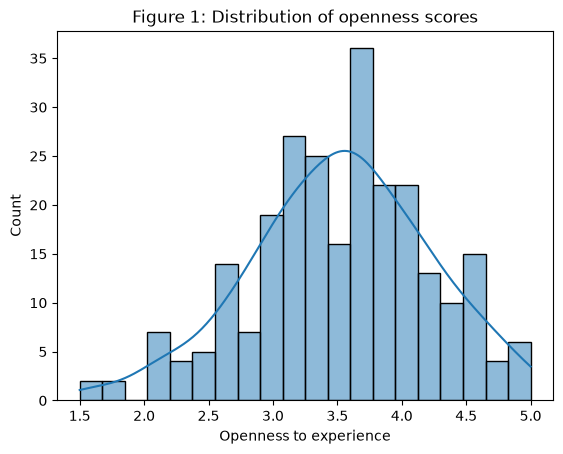

In [ ]:
sns.histplot(data=analysis, x='openness', bins=20, kde=True, stat='count')
plt.xlabel('Openness to experience')
plt.title('Figure 1: Distribution of openness scores')
plt.show()

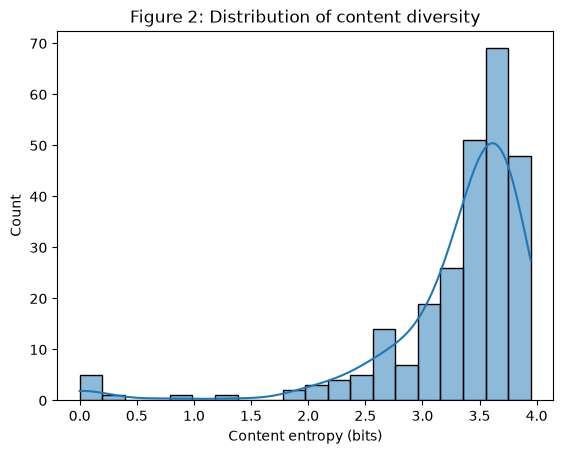

In [ ]:
sns.histplot(data=analysis, x='content_entropy', bins=20, kde=True, stat='count')
plt.xlabel('Content entropy (bits)')
plt.title('Figure 2: Distribution of content diversity')
plt.show()

Figure 1 shows that openness scores are approximately normally distributed around a mean of 3.52 (*SD* = 0.70). Figure 2 shows that content entropy is strongly negatively skewed (*M* = 3.31, *SD* = 0.69). Most participants sit between 3 and 4 bits, close to the maximum of 4.09, with a thin tail of participants who concentrate their viewing in very few categories. Nine of the ten participants below 2 bits have fewer than 100 categorised viewings, so this tail mostly reflects short watch histories.

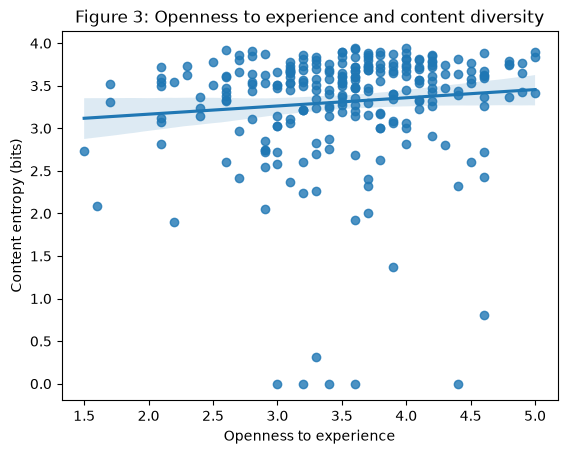

In [ ]:
sns.regplot(data=analysis, x='openness', y='content_entropy')
plt.xlabel('Openness to experience')
plt.ylabel('Content entropy (bits)')
plt.title('Figure 3: Openness to experience and content diversity')
plt.show()

In [ ]:
analysis['openness'].corr(analysis['content_entropy'])

np.float64(0.09685669362937321)

Figure 3 shows a weak positive association between openness and content entropy (*r* = .10). The fitted line slopes upward, so higher openness goes together with slightly higher content diversity. The scatter is wide and the confidence band around the line is visible, which represents a small effect. The vertical spread at every level of openness shows that the variable separates people only loosely.

## Statistical testing

In [ ]:
# OLS regression
X = analysis[['openness', 'leeftijd', 'geslacht', 'log_videos']]
X = sm.add_constant(X)
y = analysis['content_entropy']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        content_entropy   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.330
Method:                 Least Squares   F-statistic:                     32.45
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           8.40e-22
Time:                        00:20:48   Log-Likelihood:                -215.38
No. Observations:                 256   AIC:                             440.8
Df Residuals:                     251   BIC:                             458.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4745      0.265      5.558      0.0

The OLS model was significant (*F*(4, 251) = 32.45, *p* < .001), explaining 34.1% of the variance in content entropy (adjusted *R*² = .33).

Openness to experience had a significant positive effect on content entropy (*b* = 0.13, *SE* = 0.05, *t* = 2.60, *p* = .010, 95% CI [0.03, 0.23]). For each one-unit increase in openness, content entropy increased by 0.13 bits, holding the control variables constant. H1 is supported.

Log-transformed video count also had a significant positive effect (*b* = 0.21, *SE* = 0.02, *t* = 11.14, *p* < .001, 95% CI [0.17, 0.25]), confirming that participants who watched more videos had higher content diversity. Age and gender were not significant predictors.

In other words, people who scored higher on openness to experience tended to watch YouTube videos from a wider range of content categories. The effect is real but small. The openness scale runs from 1 to 5, so moving from the least to the most open person in this sample predicts about half a bit more entropy, against an observed spread of roughly 4 bits. Personality nudges how varied a person's viewing is without determining it. The strongest predictor of content diversity was the total number of videos watched, which makes sense because more viewing creates more opportunity to encounter different types of content.

## Diagnostic test

In [ ]:
# Diagnostic test: variance inflation factor for multicollinearity
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif[vif['variable'] != 'const'].round(2)

,variable,VIF
1,openness,1.01
2,leeftijd,1.02
3,geslacht,1.00
4,log_videos,1.03


All VIF values are between 1.00 and 1.03, far below the conventional threshold of 5. Multicollinearity is not a concern. The four predictors carry largely independent information, so each coefficient can be read on its own.

The regression output also reports a significant Jarque-Bera test (*JB* = 237.66, *p* < .001) with a skew of −1.48 and kurtosis of 6.68, so the residuals are not normally distributed. This follows from the ceiling in the dependent variable visible in Figure 2. With *N* = 256 the coefficient estimates remain unbiased and the standard errors are reasonably robust, but this violation is noted in the limitations.

# Discussion

## Reflection

Openness to experience predicts how varied a person's YouTube viewing is. This answers the research question, but the relationship is weak. The relationship holds after accounting for how much a person watches, but openness separates people's viewing only slightly, while the amount they watch separates it more strongly.

The result gains weight from how it was measured. Sindermann et al. (2020) linked openness to the number of news sources people said they used. Self-reported media use is often inaccurate (Parry et al., 2021), and when personality and media use are both self-reported, a shared tendency in how people answer questionnaires can by itself produce a correlation between them. Here the outcome was recorded by the platform rather than recalled by the participant, so that explanation does not apply. That the relationship still appears indicates that openness is related to what people actually watch, not only to how they describe it.

The result also explains the filter bubble concern raised in the introduction, but only in part. At the level of YouTube categories, few participants look narrow. Most watched videos from nearly every category. Where viewing does differ, personality accounts for little of the difference. This study did not observe the recommendation algorithm, so it cannot say how much diversity the algorithm adds or removes. It can say that people who differ in openness do not differ much in how diverse their viewing is, so narrow consumption cannot be explained mainly by personality either.

The strongest predictor, how much a person watches, changes how content diversity should be read. A short watch history cannot cover many categories, and it is less likely to include the kinds of videos a person watches only occasionally. Entropy computed from donated histories therefore partly measures how much someone uses the platform, not only how broad their taste is. Studies that compare content diversity between groups, such as older and younger users, need to account for viewing volume, or they will mistake lighter use for narrower taste.

## Limitations and Future Recommendations

The design is cross-sectional. Openness is treated as the predictor because personality is stable across years while viewing changes week to week, but the data cannot rule out that varied viewing cultivates openness, or that a third variable such as education drives both. Measuring personality at two points in a longitudinal panel would allow a stronger test.

Both main variables are also measured more narrowly than the concepts behind them. The openness scale covers only the intellectual curiosity and imagination facets of Big Five Factor V (Goldberg, 1992) and omits aesthetic sensitivity and preference for variety, which belong to Costa and McCrae's (1992) broader construct. Novelty seeking is more directly linked to exploring unfamiliar content than abstract thinking is, so this measure probably understates the relationship, which a full NEO-PI-R openness scale would test. On the outcome side, the 17 YouTube categories are coarse. A political interview and a celebrity interview can both be "Entertainment," so genuine variety within a category is recorded as none, which again works against the hypothesis. Topic modelling of video titles, which were part of the donation, would give a finer measure.

The shape of the outcome affects the model as well. Entropy is bounded at 4.09 bits and most participants sit near that ceiling, which explains the non-normal residuals and makes the model less able to separate viewers who are already diverse. A beta regression would suit the data better. It requires entropy rescaled to lie strictly between 0 and 1, so the five participants with an entropy of exactly zero would need a small adjustment.

The sample is selective in two ways. Only 405 of 2,463 respondents (16.4%) contributed a usable watch history, and Strycharz et al. (2024) show that willingness to donate is not random. If donors are more open than non-donors, the restricted range of the predictor would weaken the coefficient reported here. Comparing donors and non-donors on the survey variables both groups completed would show how large this bias is. Another 115 participants were lost to a non-response answer on at least one openness item. If non-response is more common among less engaged respondents, listwise deletion has left a sample more attentive than the panel it came from. Multiple imputation would retain these cases and test whether the result holds.

# References
Centerdata. (2026). *LISS panel*. Retrieved September 22, 2026, from https://www.centerdata.nl/liss-panel

Costa, P. T., & McCrae, R. R. (1992). *Revised NEO Personality Inventory (NEO-PI-R) and NEO Five-Factor Inventory (NEO-FFI) professional manual.* Psychological Assessment Resources.

Goldberg, L. R. (1992). The development of markers for the Big-Five factor structure. *Psychological Assessment*, *4*(1), 26–42. https://doi.org/10.1037/1040-3590.4.1.26

International Personality Item Pool. (n.d.). *A scientific collaboratory for the development of advanced measures of personality traits and other individual differences.* https://ipip.ori.org/

Parry, D. A., Davidson, B. I., Sewall, C. J. R., Fisher, J. T., Mieczkowski, H., & Quintana, D. S. (2021). A systematic review and meta-analysis of discrepancies between logged and self-reported digital media use. *Nature Human Behaviour*, *5*(11), 1535–1547. https://doi.org/10.1038/s41562-021-01117-5

Pariser, E. (2011). *The filter bubble: What the Internet is hiding from you.* Penguin.

Rentfrow, P. J., & Gosling, S. D. (2003). The do re mi's of everyday life: The structure and personality correlates of music preferences. *Journal of Personality and Social Psychology*, *84*(6), 1236–1256. https://doi.org/10.1037/0022-3514.84.6.1236

Shannon, C. E. (1948). A mathematical theory of communication. *Bell System Technical Journal*, *27*(3), 379–423. https://doi.org/10.1002/j.1538-7305.1948.tb01338.x

Sindermann, C., Elhai, J. D., Moshagen, M., & Montag, C. (2020). Age, gender, personality, ideological attitudes and individual differences in a person's news spectrum: How many and who might be prone to "filter bubbles" and "echo chambers" online? *Heliyon*, *6*(1), e03214. https://doi.org/10.1016/j.heliyon.2020.e03214

Strycharz, J., Meppelink, C., Zarouali, B., Araujo, T., & Voorveld, H. (2024). The blind spot in data donations: Who is (not) willing to donate digital data in social scientific research. *Computational Communication Research*, *6*(2), 1–27. https://doi.org/10.5117/CCR2024.2.3.STRY

# GenAI Disclosure

This assignment was completed with the assistance of Claude (Anthropic). Claude was used to write code for the data preparation checks, the sample size table and the diagnostic analysis. All outputs were reviewed and verified by the author.